## Ridge Regression: Solve Ill-Conditioned 

The goal of this notebook is to show how to solve an ill-conditioned linear regression problem using regularization techniques. Ill-conditioned problems can lead to unstable solutions and overfitting, so it's important to apply methods that can help stabilize the solution.

In [145]:
import numpy as np

SEED = 1713
DATASET_SIZE = 100
rng = np.random.default_rng(SEED)

## Dataset

Each dataset is generated from a known linear function with added noise.

- **Ill-conditioned dataset.** The two input features are constructed to be almost perfectly correlated — the classic recipe for multicollinearity — which can make the estimated regression coefficients unstable.


In [146]:
"""Function to estimate"""

def f(x: np.ndarray) -> np.ndarray:
    return x*3.8 + 7.12

In [147]:
"""Ill-Conditioned Dataset"""

from core.tensor import Tensor
from core.dataset import TensorDataset, DataLoader

NOISE = 3
EPS = 1e-5
SPLIT_RATIO = 0.9
MIN_X, MAX_X = -5, 5

x = np.linspace(MIN_X, MAX_X, DATASET_SIZE)
x2 = x + EPS * rng.standard_normal(DATASET_SIZE)

X = np.stack([x, x2]).T
y = f(X) + rng.standard_normal(X.shape) * NOISE

split_idx = int(len(X)*SPLIT_RATIO)
X_tr, y_tr = Tensor(X[:split_idx]), Tensor(y[:split_idx])
X_te, y_te = Tensor(X[split_idx:]), Tensor(y[split_idx:])

train_dataset = TensorDataset(X_tr, y_tr)
test_dataset = TensorDataset(X_te, y_te)

train_dataloader = DataLoader(train_dataset, len(train_dataset))
test_dataloader = DataLoader(test_dataset, len(test_dataset))

print(f"X.shape: {X.shape}, y.shape: {y.shape}")
print(f"X_tr.shape: {X_tr.shape}, y_tr.shape: {y_tr.shape}")
print(f"X_te.shape: {X_te.shape}, y_te.shape: {y_te.shape}")
print(f"condition number: k(X): {np.linalg.cond(X)}")

X.shape: (100, 2), y.shape: (100, 2)
X_tr.shape: (90, 2), y_tr.shape: (90, 2)
X_te.shape: (10, 2), y_te.shape: (10, 2)
condition number: k(X): 619926.2472806105


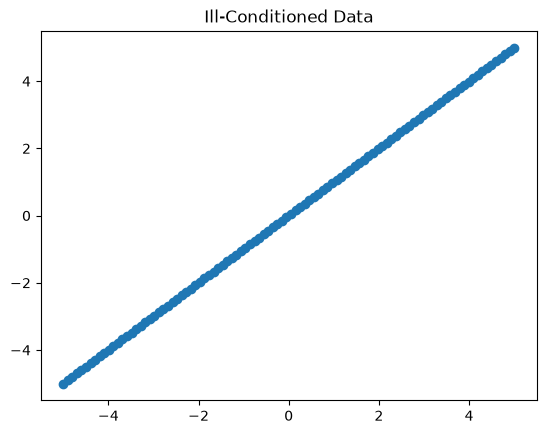

In [148]:
"""Feature correleation"""

import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.title("Ill-Conditioned Data")
plt.show()

## Model Architecture

In this section we are declaring two models: a simple linear regression model and a ridge regression model. The ridge regression model is used to solve the ill-conditioned problem by adding a regularization term to the loss function.

### Linear Regression: 
The model architecture consists of a simple linear regression model with two input features.
L2 penalty layer is applied, but with penalty coefficient set to zero, which means no regularization is applied.

### Ridge Regression: 
The model architecture consists of a ridge regression model with two input features and a regularization term.

In [149]:
from core.layers import Linear, Sequential
from core.losses import MSELoss
from core.optimizer import SGD
from core.training import Trainer
from core.training.schedulers import CosineSchedule

EPOCHS = 300
MAX_LR = 1e-2
MIN_LR = 1e-4
PENALTY = 0.5



linear = Sequential(
    Linear(2, 2)
)
loss_linear = MSELoss()
optimizer_linear = SGD(linear.parameters, MAX_LR)
scheduler_linear = CosineSchedule(MAX_LR, MIN_LR, EPOCHS)
trainer_linear = Trainer(linear, loss_linear, optimizer_linear, scheduler_linear)

ridge = Sequential(
    Linear(2, 2)
)
loss_ridge = MSELoss()
optimizer_ridge = SGD(ridge.parameters, MAX_LR, weight_decay=PENALTY)
scheduler_ridge = CosineSchedule(MAX_LR, MIN_LR, EPOCHS)
trainer_ridge = Trainer(ridge, loss_ridge, optimizer_ridge, scheduler_ridge)

# Save graph of models
#ridge.save_graph("./arch/architecture.png", arch=True)
#ridge.save_graph("./arch/forward.png", arch=False, forward=True)
#ridge.save_graph("./arch/backward.png", arch=False, backward=True)


In [150]:
EVAL_STEP = 5

""" Train loop: Linear Regression """
for i, epoch in enumerate(range(EPOCHS)):
    _ = trainer_linear.train_epoch(train_dataloader, 1)

    if i % EVAL_STEP == 0:
        _ = trainer_linear.eval(test_dataloader)

""" Train loop: Ridge Regression """
for i, epoch in enumerate(range(EPOCHS)):
    _ = trainer_ridge.train_epoch(train_dataloader, 1)

    if i % EVAL_STEP == 0:
        _ = trainer_ridge.eval(test_dataloader)

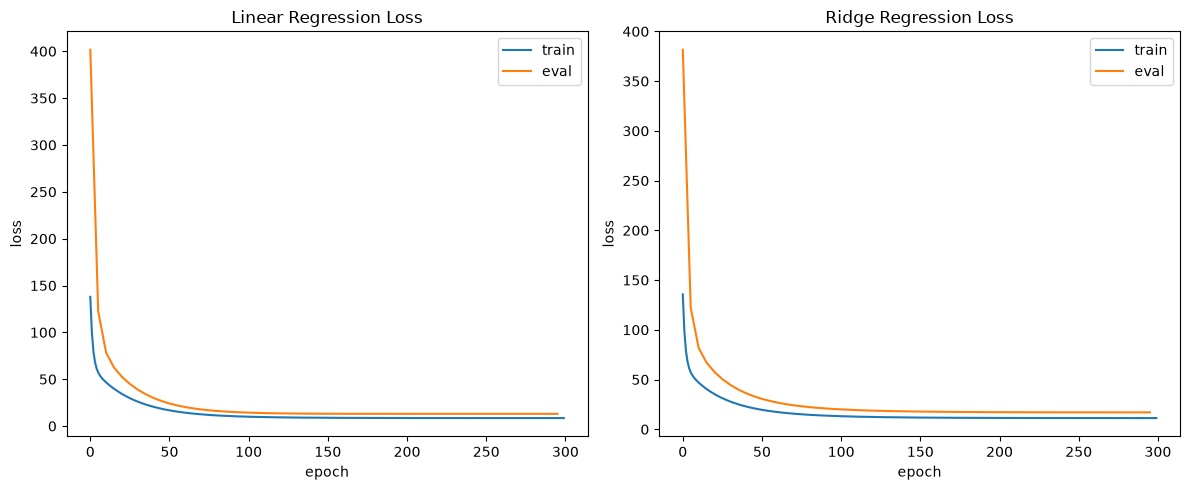

In [151]:
import matplotlib.pyplot as plt

# Plot in one windows, divided into sections
fig, (ax_loss_linear, ax_loss_ridge) = plt.subplots(1, 2, figsize=(12, 5))

# Loss ill-conditioned section
ax_loss_linear.plot(list(range(EPOCHS)), trainer_linear.train_loss, label='train')
ax_loss_linear.plot(list(range(0, EPOCHS, EVAL_STEP)), trainer_linear.eval_loss, label='eval')
ax_loss_linear.set_title('Linear Regression Loss')
ax_loss_linear.set_xlabel("epoch")
ax_loss_linear.set_ylabel("loss")
ax_loss_linear.legend()

# Loss ridge regression
ax_loss_ridge.plot(list(range(EPOCHS)), trainer_ridge.train_loss, label='train')
ax_loss_ridge.plot(list(range(0, EPOCHS, EVAL_STEP)), trainer_ridge.eval_loss, label='eval')
ax_loss_ridge.set_title('Ridge Regression Loss')
ax_loss_ridge.set_xlabel("epoch")
ax_loss_ridge.set_ylabel("loss")
ax_loss_ridge.legend()

fig.tight_layout()
plt.show()

## Predictions Residuals

### Closed Form Solution
The closed form solution for linear regression is given by the SVD decomposition of the input matrix.
We want to use the closed form solution to compare the residuals between the linear regression and ridge regression models.


In [152]:
W_true = np.array([[3.8, 0.0], [0.0, 3.8]])
b_true = np.array([7.12, 7.12])
coefs = np.vstack([W_true, b_true])

In [153]:
"""Predictions Residuals"""

import numpy as np
from core.functions import mse


A = np.hstack([X_te, np.ones((X_te.shape[0], 1))])
closed_form = A @ coefs

# Prediction
preds_linear = linear(X_te)
preds_ridge = ridge(X_te)

# Residual computation
residual_closed = mse(closed_form, y_te)
residual_linear = mse(preds_linear.data, y_te)
residual_ridge = mse(preds_ridge.data, y_te)

print(f'residual closed form: {residual_closed}')
print(f'residual linear regression: {residual_linear}')
print(f'residual ridge regression: {residual_ridge}')

residual closed form: 12.95788609781722
residual linear regression: 13.031519889831543
residual ridge regression: 16.975265502929688


## Parameters Residuals

The two main differences between linear regression and ridge regression models, are the parameters residuals, not the predictions residuals.
The parameters residuals are computed as the mean squared difference between the actual parameters of each model against the closed form solution coefficients. The parameters residuals are a measure of how well the model is able to recover the true underlying coefficients of the linear function that generated the data.

In [154]:
"""Weights Residuals"""


W_linear, b_linear = linear.parameters
W_ridge, b_ridge = ridge.parameters

linear_params = np.hstack([W_linear.data, b_linear.data.reshape(-1, 1)]).T
ridge_params = np.hstack([W_ridge.data, b_ridge.data.reshape(-1, 1)]).T

residual_linear = mse(linear_params, coefs)
residual_ridge = mse(ridge_params, coefs)

print(f'residual linear regression: {residual_linear}')
print(f'residual ridge regression: {residual_ridge}')

print('\n\n-----TRUE COEFS-----\n')
print(coefs)

print('\n\n-----LINEAR REGRESSION PARAMETERS-----\n')
print(linear_params)

print('\n-----RIDGE REGRESSION PARAMETERS-----\n')
print(ridge_params)

residual linear regression: 2.6182063573199295
residual ridge regression: 2.719447471200551


-----TRUE COEFS-----

[[3.8  0.  ]
 [0.   3.8 ]
 [7.12 7.12]]


-----LINEAR REGRESSION PARAMETERS-----

[[1.6212993 2.1743202]
 [1.7207778 1.9932467]
 [7.0547857 7.1917377]]

-----RIDGE REGRESSION PARAMETERS-----

[[1.8035648 1.8365   ]
 [1.5279225 2.0306249]
 [5.7411613 5.8583474]]
